In [8]:
import scanpy as sc
import matplotlib.pyplot as plt

adata_orig_umap = sc.read_h5ad("output/adata_orig_umap.h5ad")
adata_st_whole_umap = sc.read_h5ad("output/adata_st_whole_umap.h5ad")
adata_st_frag_umap = sc.read_h5ad("output/adata_st_frag_umap.h5ad")
adata_ft_whole_umap = sc.read_h5ad("output/adata_ft_whole_umap.h5ad")
adata_ft_frag_umap = sc.read_h5ad("output/adata_ft_frag_umap.h5ad")

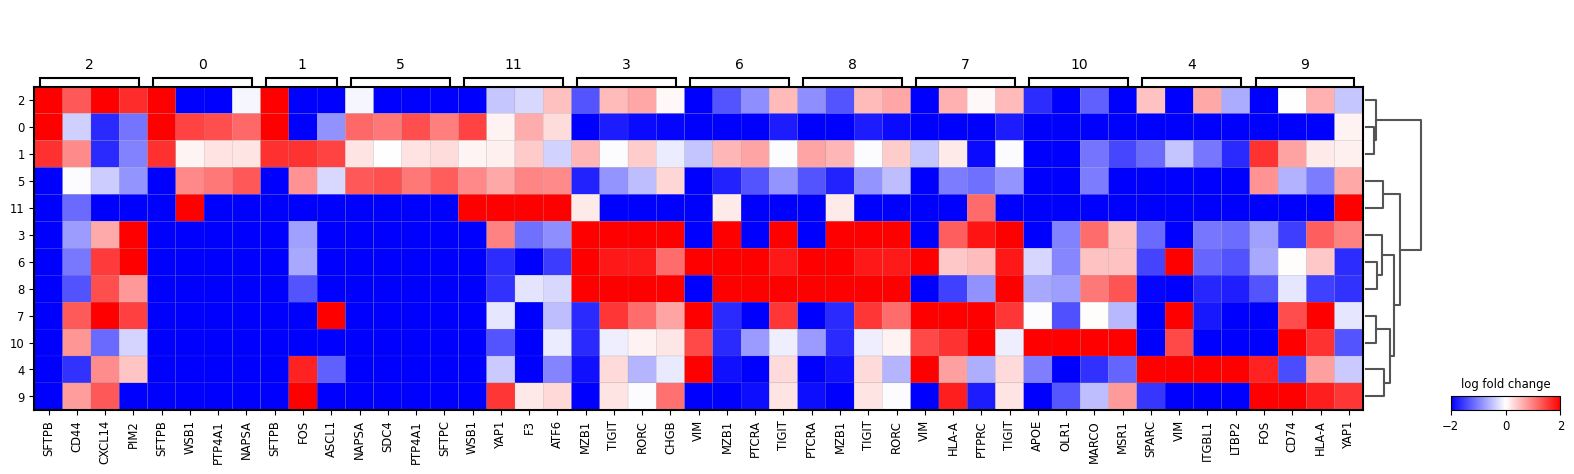

In [16]:
qc_mask = (adata_ft_whole_umap.obs["n_transcripts"] >= 5) & (adata_ft_whole_umap.obs["n_genes"] >= 4)
adata_ft_qc = adata_ft_whole_umap[qc_mask].copy()

sc.tl.dendrogram(adata_ft_qc, groupby="_leiden")
sc.tl.rank_genes_groups(adata_ft_qc, groupby="_leiden")
sc.pl.rank_genes_groups_matrixplot(
    adata_ft_qc,
    n_genes=4,
    values_to_plot="logfoldchanges",
    cmap='bwr',
    vmin=-2,
    vmax=2,
    min_logfoldchange=1,
    colorbar_title='log fold change',
    show=False
)
plt.show()

In [ ]:
def run_umap_pipeline(
    adata: sc.AnnData,
    n_pcs=300,
    n_neighbors=15,
    leiden_res=1.0,
    key_prefix="m1",
    name=""
):
    """Run standard scanpy preprocessing and UMAP"""
    print(f"\nProcessing {name}...")

    # Keep raw counts
    adata.layers["counts"] = adata.X.copy()

    # Normalize
    sc.pp.normalize_total(adata, inplace=True)
    sc.pp.log1p(adata)

    n_pcs_use = min(n_pcs, adata.n_vars - 1, 50_000)  # safety cap if huge vars
    sc.pp.pca(adata, n_comps=n_pcs_use)

    sc.pp.neighbors(
        adata,
        n_neighbors=n_neighbors,
        n_pcs=min(n_pcs_use, adata.obsm["X_pca"].shape[1]),
    )

    sc.tl.umap(adata)

    # Define the key once, consistently
    leiden_key = f"{key_prefix}_leiden" if not str(key_prefix).endswith("_") else f"{key_prefix}leiden"
    sc.tl.leiden(adata, 
                 resolution=leiden_res, 
                 key_added=leiden_key,
                 flavor="igraph",
                 n_iterations=2,
                 directed=False  # required for igraph
                )

    # store key for downstream metrics
    adata.uns["leiden_key"] = leiden_key
    print(f"  ✓ UMAP complete: {adata.obsm['X_umap'].shape}")
    return adata

In [18]:
cluster_to_label = {
    "0": "AT2_like_tumor",
    "1": "AT2_like_tumor",
    "2": "AT2_like_tumor",      
    "5": "AT1_like_tumor",
    "11": "AT1_like_tumor",      
    "10": "Macrophage",
    "4": "Stromal",
}

adata_sub = adata_ft_qc[
    adata_ft_qc.obs["_leiden"].isin(["3", "6", "7", "8", "9"])
].copy()

# Map known clusters
adata_ft_qc.obs["celltype"] = (
    adata_ft_qc.obs["_leiden"].map(cluster_to_label)
)

print(adata_ft_qc.obs["celltype"].value_counts())

celltype
AT2_like_tumor    24877
AT1_like_tumor     8958
Stromal            8310
Macrophage         2515
Name: count, dtype: int64



Processing Subcluster...
  ✓ UMAP complete: (6431, 2)


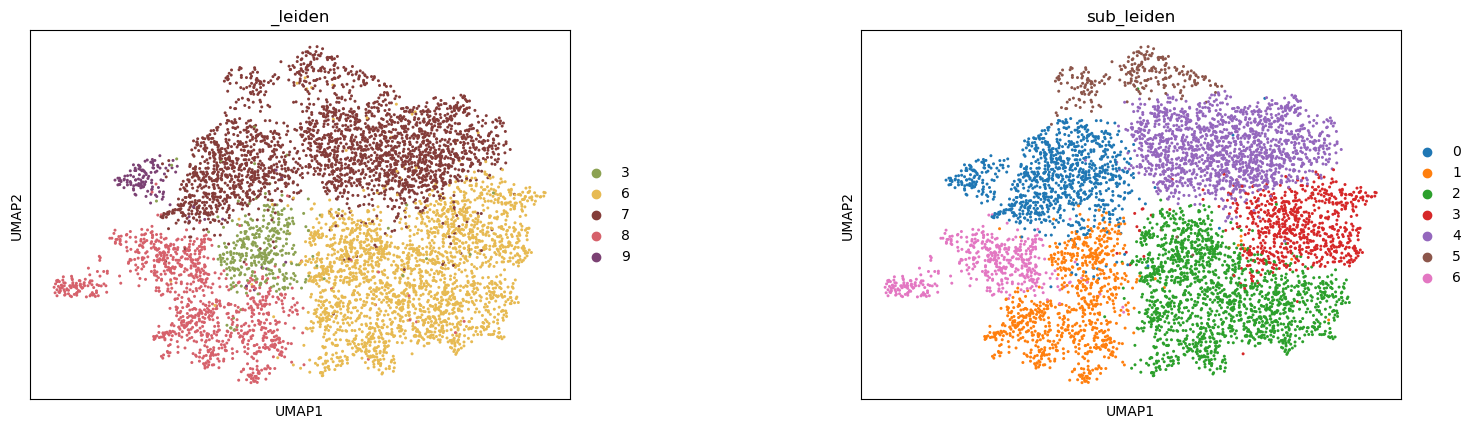

In [19]:
adata_sub = run_umap_pipeline(
    adata_sub,
    n_pcs=50,
    n_neighbors=15,
    leiden_res=0.5,
    key_prefix="sub",
    name="Subcluster"
)


sc.pl.umap(
    adata_sub,
    color=["_leiden", "sub_leiden"],
    wspace=0.4
)

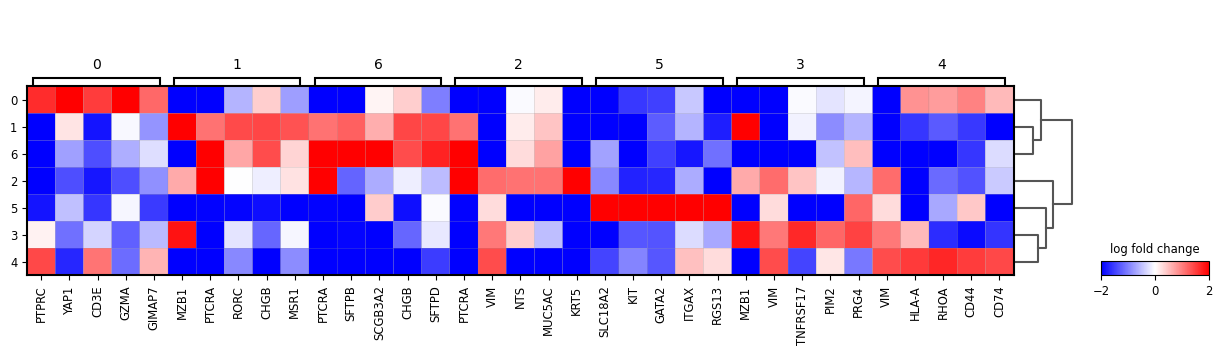

In [20]:
sc.tl.rank_genes_groups(adata_sub, groupby="sub_leiden", method="wilcoxon")
sc.pl.rank_genes_groups_matrixplot(
    adata_sub,
    n_genes=5,
    values_to_plot="logfoldchanges",
    cmap="bwr",
    vmin=-2, vmax=2,
    min_logfoldchange=1,
    colorbar_title="log fold change",
    show=True,
)

In [21]:
sub_map = {
    "0": "T_cell",
    "3": "Plasma_cell",
    "5": "Mast_cell",
    "6": "AT2_like_tumor",
}

adata_sub.obs["sub_celltype"] = (
    adata_sub.obs["sub_leiden"].map(sub_map)
)

adata_ft_qc.obs.loc[
    adata_sub.obs.index,
    "celltype"
] = adata_sub.obs["sub_celltype"]

In [22]:
adata_final = adata_ft_qc[
    adata_ft_qc.obs["celltype"].notna()
].copy()

adata_final.obs["celltype"] = (
    adata_final.obs["celltype"].astype("category")
)

print(adata_final.obs["celltype"].value_counts())

celltype
AT2_like_tumor    25339
AT1_like_tumor     8958
Stromal            8310
Macrophage         2515
T_cell             1006
Plasma_cell         729
Mast_cell           245
Name: count, dtype: int64


In [23]:
import pandas as pd
adata_orig_umap.obs["celltype"] = pd.NA
adata_st_whole_umap.obs["celltype"] = pd.NA

# Transfer
adata_orig_umap.obs.loc[
    adata_final.obs.index,
    "celltype"
] = adata_final.obs["celltype"]

adata_st_whole_umap.obs.loc[
    adata_final.obs.index,
    "celltype"
] = adata_final.obs["celltype"]

adata_orig_clean = adata_orig_umap[
    adata_orig_umap.obs["celltype"].notna()
].copy()

adata_st_clean = adata_st_whole_umap[
    adata_st_whole_umap.obs["celltype"].notna()
].copy()

adata_orig_clean.obs["celltype"] = adata_orig_clean.obs["celltype"].astype("category")
adata_st_clean.obs["celltype"] = adata_st_clean.obs["celltype"].astype("category")

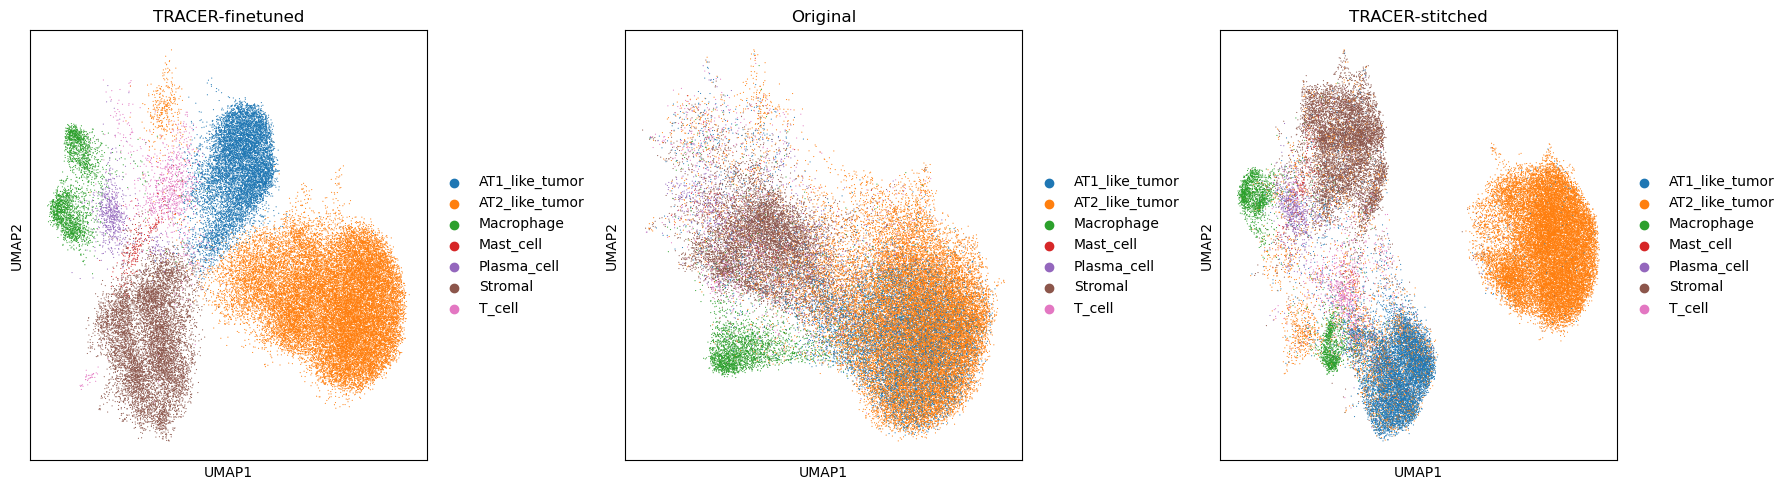

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sc.pl.umap(
    adata_final,
    color="celltype",
    ax=axes[0],
    show=False,
    title="TRACER-finetuned"
)

sc.pl.umap(
    adata_orig_clean,
    color="celltype",
    ax=axes[1],
    show=False,
    title="Original"
)

sc.pl.umap(
    adata_st_clean,
    color="celltype",
    ax=axes[2],
    show=False,
    title="TRACER-stitched"
)

plt.tight_layout()
plt.show()

categories: AT1_like_tumor, AT2_like_tumor, Macrophage, etc.
var_group_labels: AT2_like_tumor, AT1_like_tumor, Macrophages, etc.


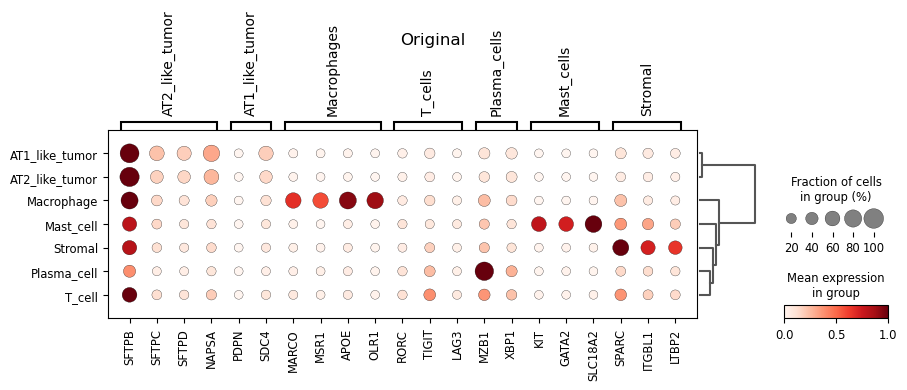

categories: AT1_like_tumor, AT2_like_tumor, Macrophage, etc.
var_group_labels: AT2_like_tumor, AT1_like_tumor, Macrophages, etc.


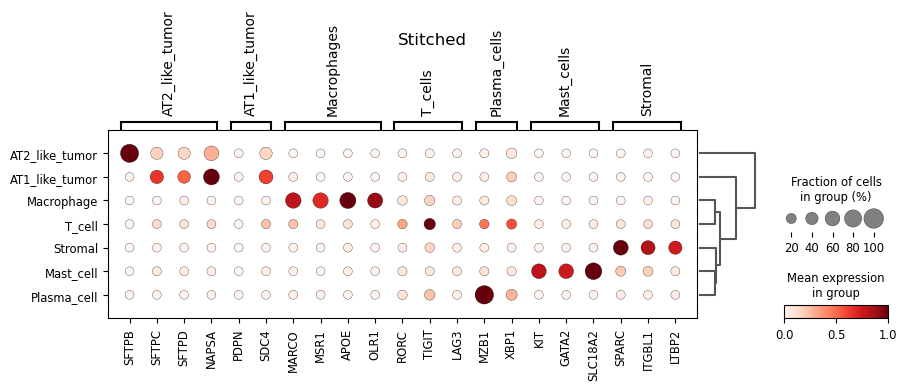

categories: AT1_like_tumor, AT2_like_tumor, Macrophage, etc.
var_group_labels: AT2_like_tumor, AT1_like_tumor, Macrophages, etc.


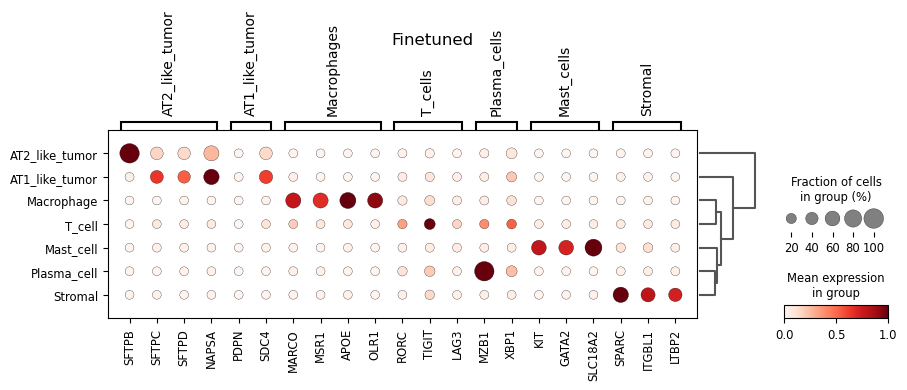

In [30]:
marker_dict = {
    "AT2_like_tumor": ["SFTPB", "SFTPC", "SFTPD", "NAPSA"],
    "AT1_like_tumor": ["PDPN", "SDC4"],
    "Macrophages": ["MARCO", "MSR1", "APOE", "OLR1"],
    "T_cells": ["RORC", "TIGIT", "LAG3"],
    "Plasma_cells": ["MZB1", "XBP1"],
    "Mast_cells": ["KIT", "GATA2", "SLC18A2"],
    "Stromal": ["SPARC", "ITGBL1", "LTBP2"],
}

for adata, name in [
    (adata_orig_clean, "Original"),
    (adata_st_clean, "Stitched"),
    (adata_final, "Finetuned"),
]:
    
    sc.pl.dotplot(
        adata,
        marker_dict,
        groupby="celltype",
        standard_scale="group",
        dendrogram=True,
        vmin=0,
        smallest_dot=40,
        title=name,
        show=False
    )
    
    plt.show()

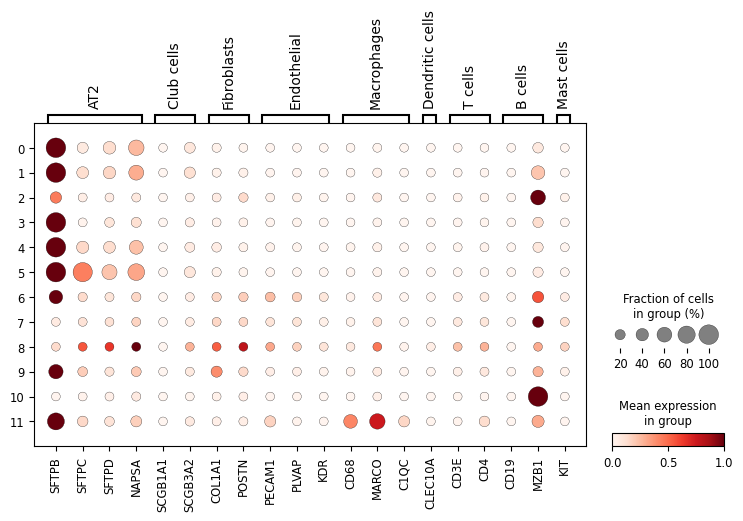

In [10]:
marker_genes = {
    "AT2": ["SFTPB", "SFTPC", "SFTPD", "NAPSA"],
    "Club cells": ["SCGB1A1", "SCGB3A2"],
    "Fibroblasts": ["COL1A1", "POSTN"],
    "Endothelial": ["PECAM1", "PLVAP", "KDR"],
    "Macrophages": ["CD68", "MARCO", "C1QC"],
    "Dendritic cells": ["CLEC10A"],
    "T cells": ["CD3E", "CD4"],
    "B cells": ["CD19", "MZB1"],
    "Mast cells": ["KIT"]
}
sc.pl.dotplot(
    adata_orig_umap,
    marker_genes,
    groupby='_leiden',
    standard_scale="group",
    dendrogram=False,
    vmin=0.,
    smallest_dot=40,
    show=False
)
plt.savefig(f"plot/lung_cancer_original_dotplot.png", dpi=300, bbox_inches="tight")
plt.show()

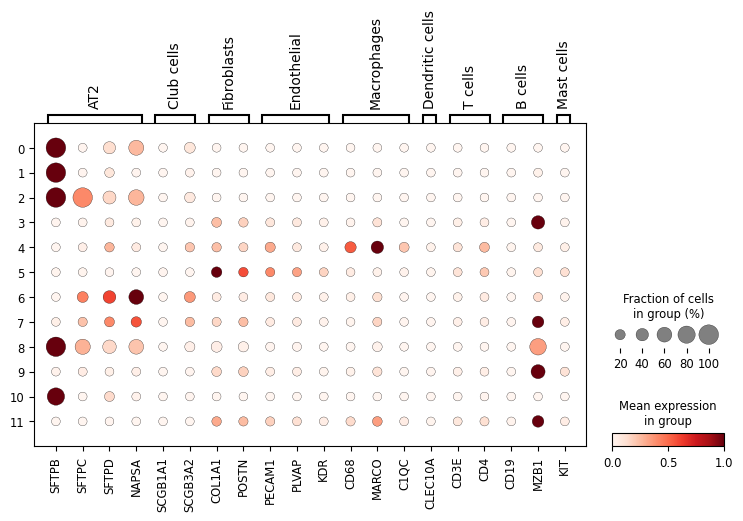

In [11]:
sc.pl.dotplot(
    adata_st_whole_umap,
    marker_genes,
    groupby='_leiden',
    standard_scale="group",
    dendrogram=False,
    vmin=0.,
    smallest_dot=40,
    show=False
)
plt.savefig(f"plot/lung_cancer_stitched_dotplot.png", dpi=300, bbox_inches="tight")
plt.show()

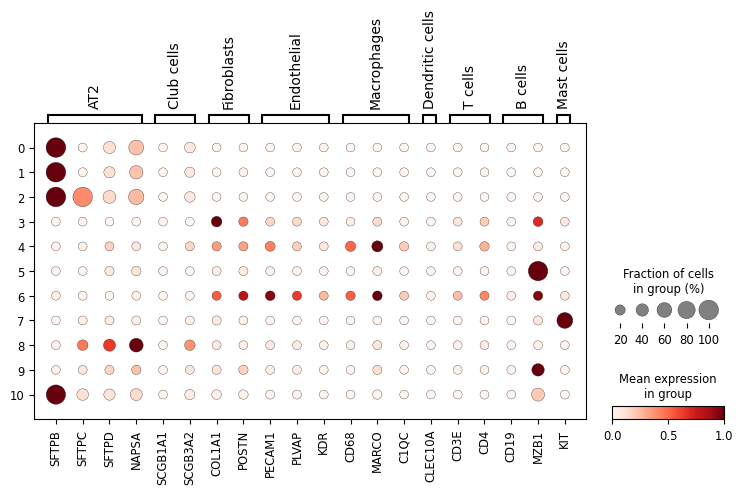

In [12]:
sc.pl.dotplot(
    adata_ft_whole_umap,
    marker_genes,
    groupby='_leiden',
    standard_scale="group",
    dendrogram=False,
    vmin=0.,
    smallest_dot=40,
    show=False
)
plt.savefig(f"plot/lung_cancer_finetuned_dotplot.png", dpi=300, bbox_inches="tight")
plt.show()

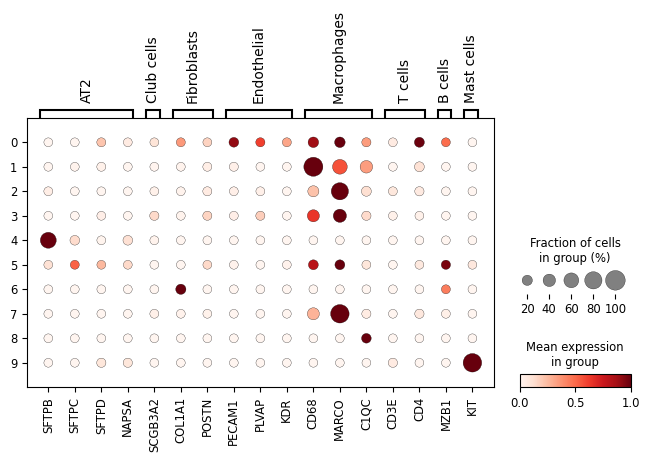

In [13]:
marker_genes = {
    "AT2": ["SFTPB", "SFTPC", "SFTPD", "NAPSA"],
    "Club cells": ["SCGB3A2"],
    "Fibroblasts": ["COL1A1", "POSTN"],
    "Endothelial": ["PECAM1", "PLVAP", "KDR"],
    "Macrophages": ["CD68", "MARCO", "C1QC"],
    "T cells": ["CD3E", "CD4"],
    "B cells": ["MZB1"],
    "Mast cells": ["KIT"]
}

sc.pl.dotplot(
    adata_ft_frag_umap,
    marker_genes,
    groupby='_leiden',
    standard_scale="group",
    dendrogram=False,
    vmin=0.,
    smallest_dot=40,
    show=False
)
plt.savefig(f"plot/lung_cancer_finetuned_partial_pseudo_cell_dotplot.png", dpi=300, bbox_inches="tight")
plt.show()

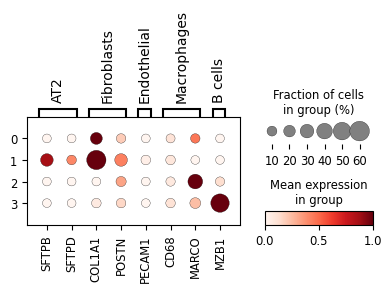

In [14]:
marker_genes = {
    "AT2": ["SFTPB", "SFTPD"],
    "Fibroblasts": ["COL1A1", "POSTN"],
    "Endothelial": ["PECAM1"],
    "Macrophages": ["CD68", "MARCO"],
    "B cells": ["MZB1"],
}
sc.pl.dotplot(
    adata_st_frag_umap,
    marker_genes,
    groupby='_leiden',
    standard_scale="group",
    dendrogram=False,
    vmin=0.,
    smallest_dot=40,
    show=False
)
plt.savefig(f"plot/lung_cancer_stitched_partial_pseudo_cell_dotplot.png", dpi=300, bbox_inches="tight")
plt.show()

categories: 0, 1, 2, etc.
var_group_labels: 0, 1, 2, etc.


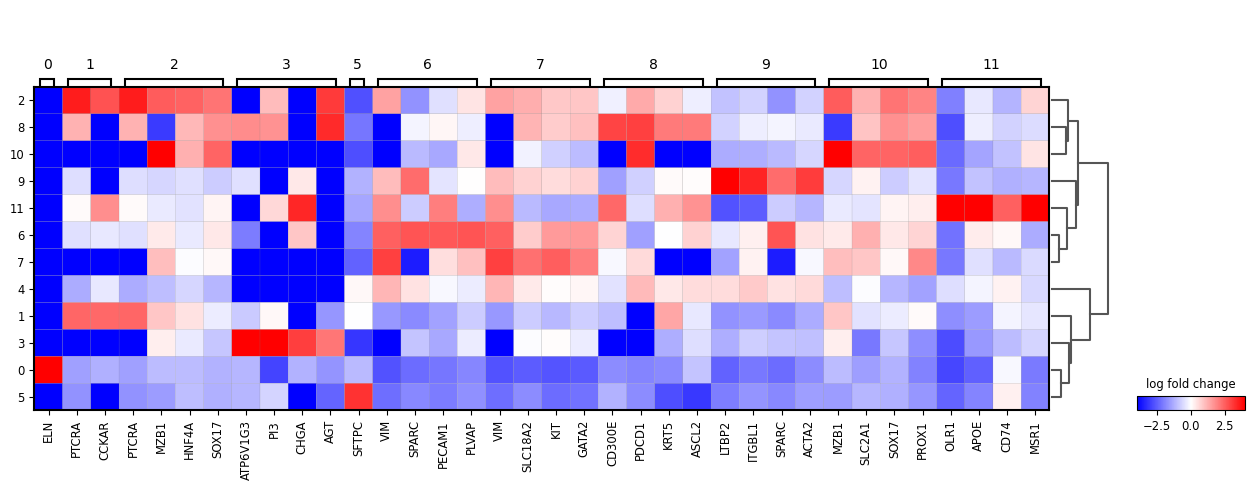

In [27]:
sc.tl.rank_genes_groups(adata_orig_umap, groupby="_leiden")
sc.pl.rank_genes_groups_matrixplot(
    adata_orig_umap,
    n_genes=4,
    values_to_plot="logfoldchanges",
    cmap='bwr',
    vmin=-4,
    vmax=4,
    min_logfoldchange=2,
    colorbar_title='log fold change',
    show=False
)
plt.savefig(f"plot/lung_cancer_original_matrixplot.png", dpi=300, bbox_inches="tight")
plt.show()

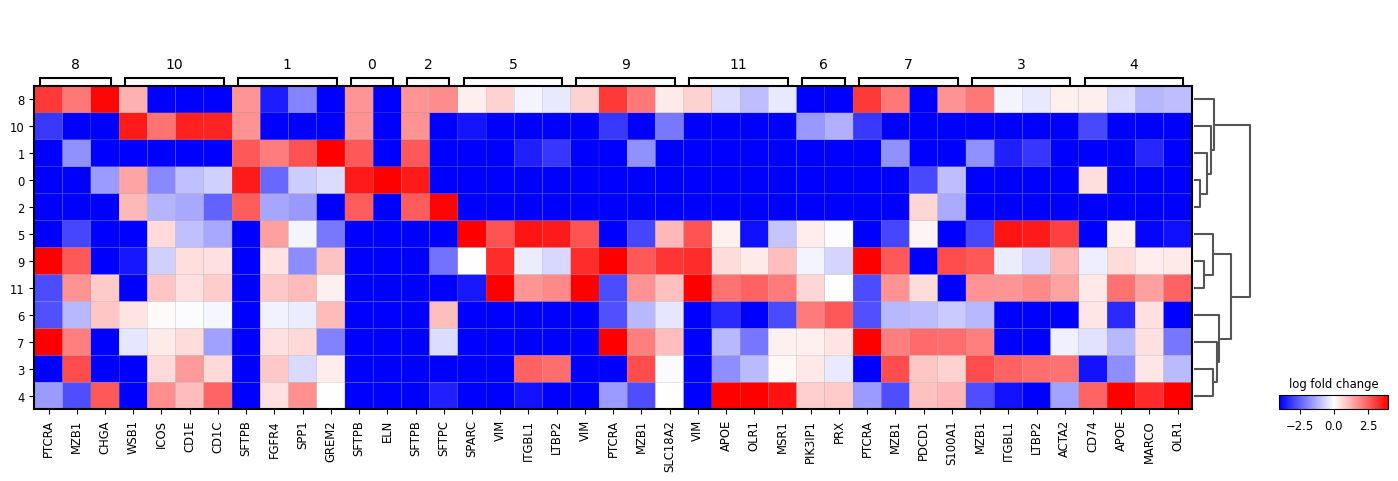

In [26]:
sc.tl.rank_genes_groups(adata_st_whole_umap, groupby="_leiden")
sc.pl.rank_genes_groups_matrixplot(
    adata_st_whole_umap,
    n_genes=4,
    values_to_plot="logfoldchanges",
    cmap='bwr',
    vmin=-4,
    vmax=4,
    min_logfoldchange=2,
    colorbar_title='log fold change',
    show=False
)
plt.savefig(f"plot/lung_cancer_stitched_matrixplot.png", dpi=300, bbox_inches="tight")
plt.show()

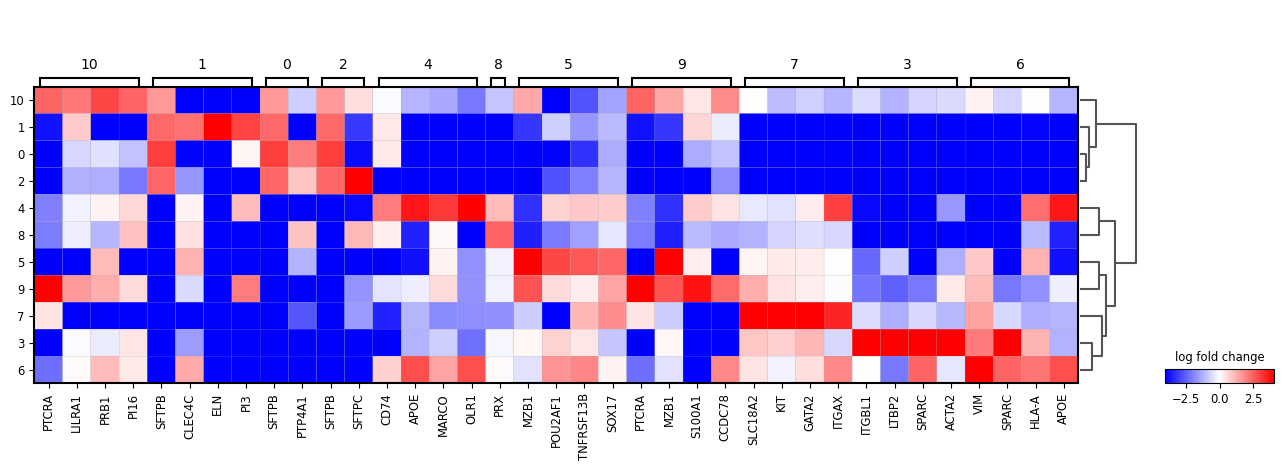

In [25]:
sc.tl.rank_genes_groups(adata_ft_whole_umap, groupby="_leiden")
sc.pl.rank_genes_groups_matrixplot(
    adata_ft_whole_umap,
    n_genes=4,
    values_to_plot="logfoldchanges",
    cmap='bwr',
    vmin=-4,
    vmax=4,
    min_logfoldchange=2,
    colorbar_title='log fold change',
    show=False
)
plt.savefig(f"plot/lung_cancer_finetuned_matrixplot.png", dpi=300, bbox_inches="tight")
plt.show()

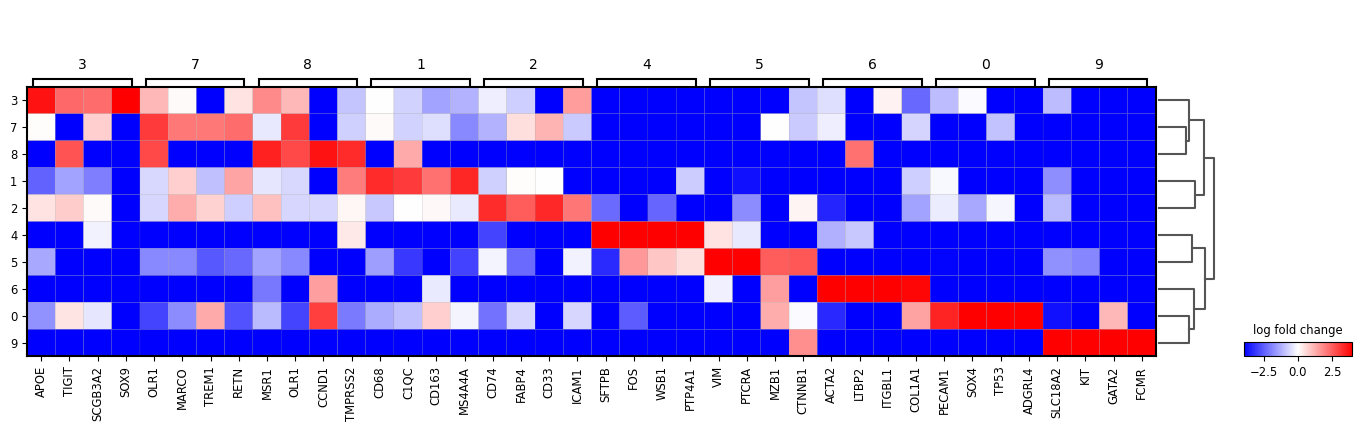

In [31]:
sc.tl.rank_genes_groups(adata_ft_frag_umap, groupby="_leiden")
sc.pl.rank_genes_groups_matrixplot(
    adata_ft_frag_umap,
    n_genes=4,
    values_to_plot="logfoldchanges",
    cmap='bwr',
    vmin=-4,
    vmax=4,
    min_logfoldchange=2,
    colorbar_title='log fold change',
    show=False
)
plt.savefig(f"plot/lung_cancer_partial_pseudocell_matrixplot.png", dpi=300, bbox_inches="tight")
plt.show()